Optional Task

Apply all the things your have learned till now on

Insurance Dataset

Dataset you use for Session 16’s Optional Task

Another new dataset (Use Github or Kaggle to get datasets)


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

1. LOAD AND CLEAN THE DATA


In [2]:
# Load the dataset
df = pd.read_csv("insurance_2.csv")

# Drop rows where critical categorical info is completely missing
df = df.dropna(subset=["sex", "smoker", "region"])

# Convert numeric columns safely now that corrupted rows are gone
df["age"] = df["age"].astype(float).astype(int)  # Handles float-like strings safely
df["bmi"] = df["bmi"].astype(float)
df["children"] = df["children"].astype(int)

# Handle duplicate values
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()

print(f"Data successfully cleaned. Current shape: {df.shape}")

Data successfully cleaned. Current shape: (1335, 6)


2. EXPLORATORY DATA ANALYSIS (EDA)


C:\Users\OMKAR\AppData\Local\Temp\ipykernel_27636\2105730954.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="smoker", palette="Set2", ax=axes[1, 0])


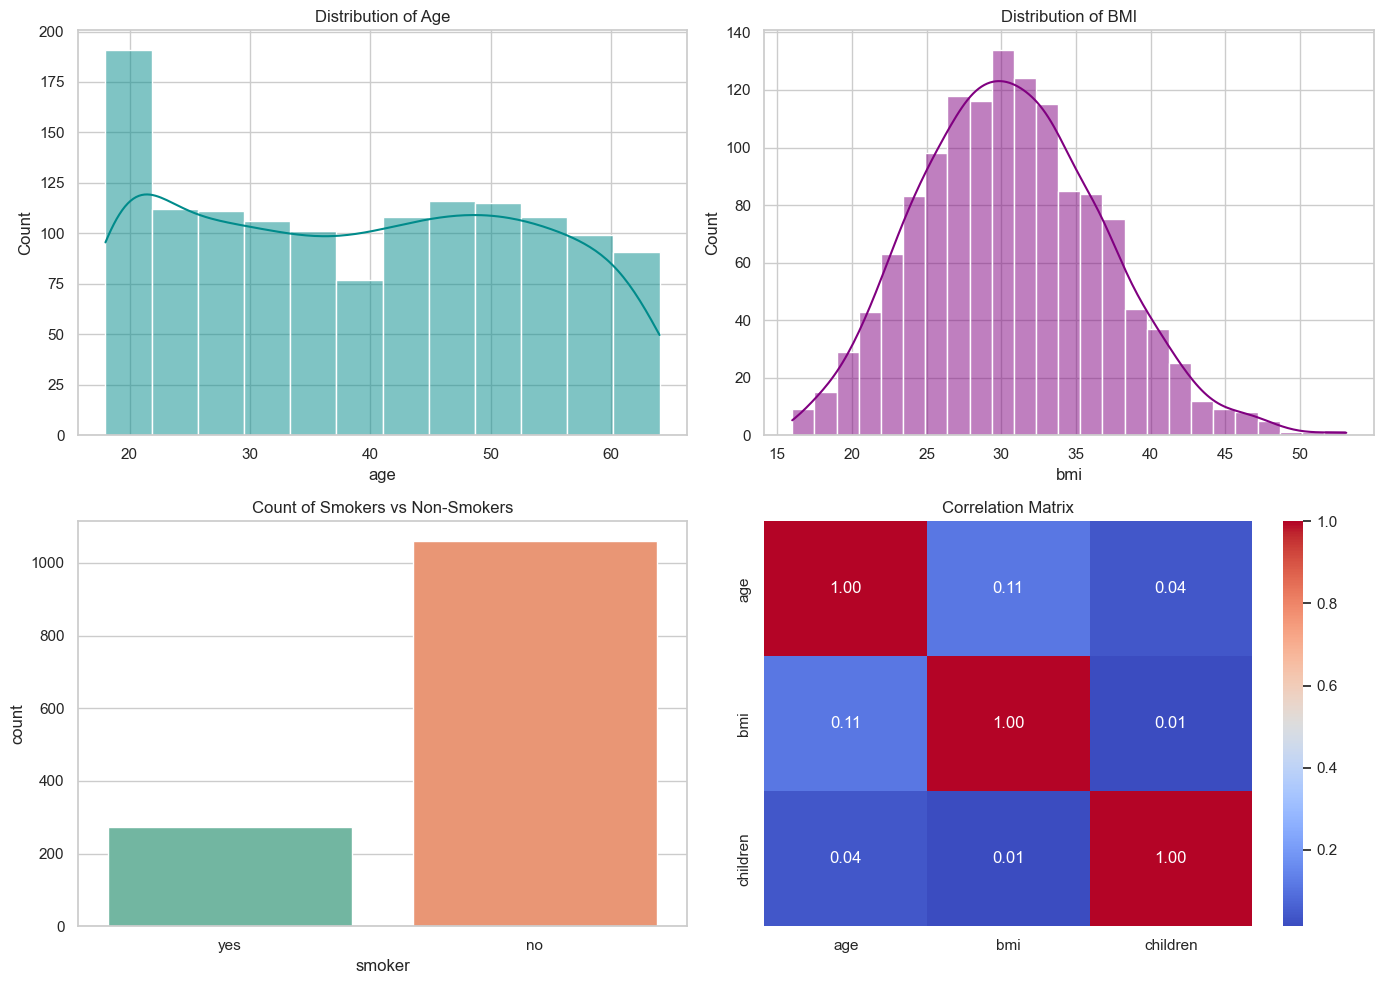

In [4]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram - Age Distribution
sns.histplot(df["age"], kde=True, color="darkcyan", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Age")

# Histogram - BMI Distribution
sns.histplot(df["bmi"], kde=True, color="purple", ax=axes[0, 1])
axes[0, 1].set_title("Distribution of BMI")

#  Count Plot - Smoker Distribution
sns.countplot(data=df, x="smoker", palette="Set2", ax=axes[1, 0])
axes[1, 0].set_title("Count of Smokers vs Non-Smokers")

#  Heatmap - Correlation Matrix of existing numeric features
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()


3. SPLIT & FEATURE PREPROCESSING PIPELINE


In [ ]:
# Since there is no target column, X is just your entire dataframe
X = df.copy()

# Encode all categorical features using One-Hot Encoding
categorical_cols = ["sex", "smoker", "region"]
X_encoded = pd.get_dummies(X, columns=categorical_cols)

# Scale all numeric features
numeric_features = ["age", "bmi", "children"]
scaler = StandardScaler()

X_scaled = X_encoded.copy()
X_scaled[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])

print("Data Pipeline Completed ")
print(f"Final Preprocessed Feature Matrix Shape: {X_scaled.shape}")

# Another new dataset (Use Github or Kaggle to get datasets)

LOAD AND CLEAN THE DATA


In [5]:
df = pd.read_csv("final_cars_datasets.csv")

print("Data Profiling ")
print(f"Initial Shape: {df.shape}")

# Drop unnecessary index column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Check for missing values
print(f"Missing Values per Column:\n{df.isnull().sum()}")

# Remove duplicates if any exist
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()

print(f"Cleaned Shape: {df.shape}")


Data Profiling 
Initial Shape: (2318, 11)
Missing Values per Column:
price              0
mark               0
model              0
year               0
mileage            0
engine_capacity    0
transmission       0
drive              0
hand_drive         0
fuel               0
dtype: int64
Cleaned Shape: (2318, 10)


EXPLORATORY DATA ANALYSIS (EDA)


C:\Users\OMKAR\AppData\Local\Temp\ipykernel_27636\2496123346.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


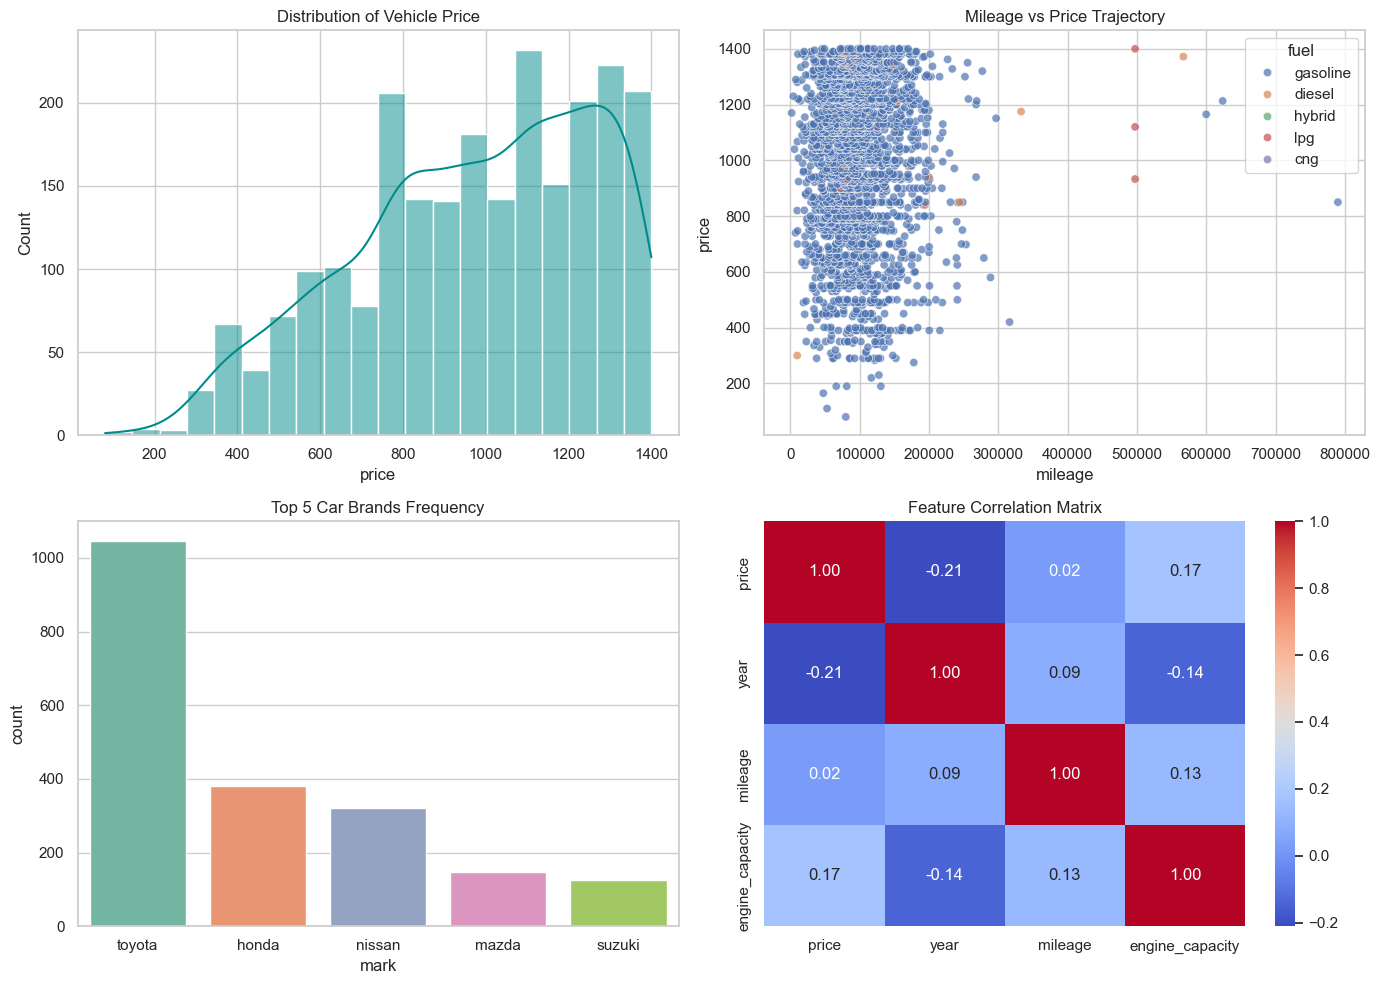

In [ ]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of Target Variable (Price)
sns.histplot(df["price"], kde=True, color="darkcyan", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Vehicle Price")

# Scatter Plot: Mileage vs Price
sns.scatterplot(
    data=df, x="mileage", y="price", hue="fuel", alpha=0.7, ax=axes[0, 1]
)
axes[0, 1].set_title("Mileage vs Price Trajectory")

# Count Plot: Top 5 Most Common Car Brands (Marks)
top_marks = df["mark"].value_counts().iloc[:5].index
sns.countplot(
    data=df[df["mark"].isin(top_marks)],
    x="mark",
    palette="Set2",
    order=top_marks,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Top 5 Car Brands Frequency")

# Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(
    numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 1]
)
axes[1, 1].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()


SPLIT & FEATURE PREPROCESSING PIPELINE


In [8]:
# Split into independent inputs (X) and target outputs (y)
X = df.drop(columns=["price"])
y = df["price"]

# Identify categoric features for One-Hot Encoding
categorical_cols = [
    "mark",
    "model",
    "transmission",
    "drive",
    "hand_drive",
    "fuel",
]
X_encoded = pd.get_dummies(X, columns=categorical_cols)

# Scale continuous numerical features using Z-score standardization
numeric_features = ["year", "mileage", "engine_capacity"]
scaler = StandardScaler()

X_scaled = X_encoded.copy()
X_scaled[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])

print("Pipeline Complete ")
print(f"Final Preprocessed Matrix Shape: {X_scaled.shape}")

Pipeline Complete 
Final Preprocessed Matrix Shape: (2318, 303)
